In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from peft import LoraConfig, get_peft_model, TaskType

train_ood = pd.read_csv("../data/processed/train_ood.csv")
test_ood  = pd.read_csv("../data/processed/test_ood.csv")

label2id = {'normal': 0, 'promo': 1, 'smish': 2}
id2label = {v: k for k, v in label2id.items()}

In [3]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text_clean'], padding='max_length',
                     truncation=True, max_length=128)  # ← 128 → 256

def make_ds(df):
    df = df[['text_clean', 'label']].copy()
    df['label'] = df['label'].map(label2id)
    ds = Dataset.from_pandas(df)
    ds = ds.map(tokenize, batched=True)
    ds = ds.remove_columns(['text_clean'])
    ds = ds.rename_column('label', 'labels')
    return ds

train_ds = make_ds(train_ood)
test_ds  = make_ds(test_ood)
print(train_ds, test_ds)

Map:   0%|          | 0/3525 [00:00<?, ? examples/s]

Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 3525
}) Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 3480
})


In [4]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                    # ← 8 → 16
    lora_alpha=32,           # ← 16 → 32
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],  # ← expand
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544


In [5]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
from transformers import TrainingArguments, Trainer

# Class weights
label2id = {'normal': 0, 'promo': 1, 'smish': 2}
cw = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=train_ood['label'].map(label2id).values
)
print("Class weights:", cw)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(cw, dtype=torch.float).to(logits.device)
        )
        loss = loss_fct(logits.view(-1, 3), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }

args = TrainingArguments(
    output_dir='../results/models/lora_v2',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,
    lr_scheduler_type='cosine',
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to='none',
    seed=42,
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

Class weights: [0.9437751  1.35524798 0.83156405]
Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.296437,0.232398,0.947126,0.945048
2,0.102252,0.448156,0.933621,0.935216
3,0.047740,0.118316,0.971839,0.970284
4,0.021246,0.119090,0.974425,0.973383
5,0.017818,0.120827,0.974713,0.973641


TrainOutput(global_step=1105, training_loss=0.10889965158242446, metrics={'train_runtime': 481.0884, 'train_samples_per_second': 36.636, 'train_steps_per_second': 2.297, 'total_flos': 1203296337216000.0, 'train_loss': 0.10889965158242446, 'epoch': 5.0})

In [6]:
import json
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix

# Best model দিয়ে prediction
preds_out = trainer.predict(test_ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

print("=" * 60)
print("LoRA v2 — OOD Test (Best Model)")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
print("\n", classification_report(y_true, y_pred,
                                  target_names=['normal','promo','smish']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Save results
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

results = {
    "timestamp": str(datetime.now()),
    "model": "XLM-R + LoRA v2 (r=16, 4 modules, weighted, max_len=128)",
    "trainable_params": trainable,
    "total_params": total,
    "trainable_pct": 100 * trainable / total,
    "ood": {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average='macro')),
    },
    "per_class_f1": {
        "normal": float(f1_score(y_true, y_pred, average=None)[0]),
        "promo":  float(f1_score(y_true, y_pred, average=None)[1]),
        "smish":  float(f1_score(y_true, y_pred, average=None)[2]),
    },
}

with open("../results/lora_v2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Saved: results/lora_v2_results.json")

# Save model
trainer.save_model("../results/models/lora_v2_best")
print("✅ Model saved: results/models/lora_v2_best")

LoRA v2 — OOD Test (Best Model)
Accuracy : 0.9747
Macro F1 : 0.9736

               precision    recall  f1-score   support

      normal       0.98      0.99      0.98      1243
       promo       0.97      0.96      0.96       841
       smish       0.98      0.97      0.97      1396

    accuracy                           0.97      3480
   macro avg       0.97      0.97      0.97      3480
weighted avg       0.97      0.97      0.97      3480


Confusion Matrix:
[[1233    5    5]
 [   6  808   27]
 [  23   22 1351]]

✅ Saved: results/lora_v2_results.json
✅ Model saved: results/models/lora_v2_best


In [7]:
import os
import json

hard_results = {}
for split_name in ['url_holdout', 'phone_holdout']:
    path = f"../data/processed/test_{split_name}.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        ds = make_ds(df)
        preds_out = trainer.predict(ds)
        y_pred = np.argmax(preds_out.predictions, axis=-1)
        y_true = preds_out.label_ids

        hard_results[split_name] = {
            "n": len(df),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average='macro')),
        }
        print(f"\n{split_name} (n={len(df)}):")
        print(f"  Accuracy: {hard_results[split_name]['accuracy']:.4f}")
        print(f"  Macro F1: {hard_results[split_name]['macro_f1']:.4f}")
    else:
        print(f"⚠️ Not found: {path}")

with open("../results/lora_v2_hard_splits.json", "w") as f:
    json.dump(hard_results, f, indent=2)
print("\n✅ Saved: results/lora_v2_hard_splits.json")

⚠️ Not found: ../data/processed/test_url_holdout.csv
⚠️ Not found: ../data/processed/test_phone_holdout.csv

✅ Saved: results/lora_v2_hard_splits.json


In [10]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Test splits — সঠিক নাম দিয়ে
TEST_FILES = {
    "B1: Fully-Unseen Smish":  "test_hard.csv",
    "B2: URL Holdout":          "test_hard2.csv",
    "B3: Phone Holdout":        "test_hard3.csv",
    "Campaign: Template Holdout": "test_campaign.csv",
}

results = {}
for split_name, fname in TEST_FILES.items():
    path = f"../data/processed/{fname}"
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"⚠️ Skip {fname}")
        continue

    # text_clean column আছে কিনা
    if 'text_clean' not in df.columns:
        print(f"⚠️ {fname}: no text_clean column, skipping")
        continue

    ds = make_ds(df)
    preds_out = trainer.predict(ds)
    y_pred = np.argmax(preds_out.predictions, axis=-1)
    y_true = preds_out.label_ids

    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    per_class = f1_score(y_true, y_pred, average=None).tolist()

    results[split_name] = {
        "file":        fname,
        "n":           len(df),
        "accuracy":    float(acc),
        "macro_f1":    float(mf1),
        "per_class_f1": per_class,
    }

    print(f"\n{'='*65}")
    print(f"{split_name}  (n={len(df)})")
    print(f"{'='*65}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro F1 : {mf1:.4f}")
    print(f"  Per-class F1: normal={per_class[0]:.4f}  "
          f"promo={per_class[1]:.4f}  smish={per_class[2]:.4f}")

# Save
with open("../results/lora_v2_hard_splits.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"\n✅ Saved: results/lora_v2_hard_splits.json")

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]


B1: Fully-Unseen Smish  (n=1267)
  Accuracy : 0.9645
  Macro F1 : 0.3273
  Per-class F1: normal=0.0000  promo=0.0000  smish=0.9819


Map:   0%|          | 0/2107 [00:00<?, ? examples/s]


B2: URL Holdout  (n=2107)
  Accuracy : 0.9748
  Macro F1 : 0.9707
  Per-class F1: normal=0.9735  promo=0.9586  smish=0.9800


Map:   0%|          | 0/2843 [00:00<?, ? examples/s]


B3: Phone Holdout  (n=2843)
  Accuracy : 0.9866
  Macro F1 : 0.9802
  Per-class F1: normal=0.9812  promo=0.9683  smish=0.9912


Map:   0%|          | 0/1407 [00:00<?, ? examples/s]


Campaign: Template Holdout  (n=1407)
  Accuracy : 0.9858
  Macro F1 : 0.9857
  Per-class F1: normal=0.9883  promo=0.9847  smish=0.9842

✅ Saved: results/lora_v2_hard_splits.json


In [11]:
import pandas as pd

# B1-এর training vs test-এর তুলনা
tr = pd.read_csv("../data/processed/train_hard.csv")
te = pd.read_csv("../data/processed/test_hard.csv")

print("train_hard.csv labels:", tr['label'].value_counts().to_dict())
print("test_hard.csv  labels:", te['label'].value_counts().to_dict())

# URL / Phone distribution
print("\ntrain_hard has_url :", tr['has_url'].value_counts().to_dict())
print("test_hard  has_url :", te['has_url'].value_counts().to_dict())
print("\ntrain_hard has_phone:", tr['has_phone'].value_counts().to_dict())
print("test_hard  has_phone:", te['has_phone'].value_counts().to_dict())

train_hard.csv labels: {'normal': 2488, 'promo': 1708, 'smish': 1542}
test_hard.csv  labels: {'smish': 1267}

train_hard has_url : {False: 4051, True: 1687}
test_hard  has_url : {False: 1267}

train_hard has_phone: {False: 5379, True: 359}
test_hard  has_phone: {True: 801, False: 466}


In [12]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# সম্পূর্ণ ডেটা লোড
df = pd.read_csv("../data/processed/cleaned.csv")

# ১. smish-only dataset
smish = df[df['label'] == 'smish'].reset_index(drop=True)
print(f"Total smish: {len(smish)}")

# ২. URL/Phone বাদ দিয়ে template extract
def strip_entities(t):
    return re.sub(r'\[URL\]|\[PHONE\]', '', str(t)).strip()

smish['stripped'] = smish['text_clean'].apply(strip_entities)

# ৩. TF-IDF + KMeans
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=3000)
X = vec.fit_transform(smish['stripped'])

km = KMeans(n_clusters=15, random_state=42, n_init=10)
smish['campaign'] = km.fit_predict(X)

print("\nCampaign distribution:")
print(smish['campaign'].value_counts())

# ৪. ক্যাম্পেইন-ভিত্তিক split — ৪টি ক্যাম্পেইন test-এ, বাকিগুলো train-এ
np.random.seed(42)
campaigns = smish['campaign'].unique()
np.random.shuffle(campaigns)
test_camps = campaigns[:4]  # ৪টি unseen ক্যাম্পেইন
train_camps = campaigns[4:]

train_smish = smish[smish['campaign'].isin(train_camps)]
test_smish  = smish[smish['campaign'].isin(test_camps)]

# ৫. Non-smish যোগ করুন
nonsmish = df[df['label'] != 'smish'].sample(frac=0.7, random_state=42)

train_unseen = pd.concat([train_smish, nonsmish]).reset_index(drop=True)
test_unseen  = pd.concat([
    test_smish,
    df[df['label'] != 'smish'].drop(nonsmish.index)
]).reset_index(drop=True)

print(f"\nNew Unseen-Attack Split:")
print(f"  Train: {train_unseen.shape}, labels: {train_unseen['label'].value_counts().to_dict()}")
print(f"  Test : {test_unseen.shape},  labels: {test_unseen['label'].value_counts().to_dict()}")
print(f"  Test campaigns: {sorted(test_camps.tolist())}")
print(f"  Train campaigns: {sorted(train_camps.tolist())}")

# ৬. Save
train_unseen.to_csv("../data/processed/train_unseen_attack.csv", index=False)
test_unseen.to_csv("../data/processed/test_unseen_attack.csv", index=False)
print("\n✅ Saved: train_unseen_attack.csv, test_unseen_attack.csv")

Total smish: 2809

Campaign distribution:
campaign
1     670
13    352
0     218
11    184
4     175
12    152
7     143
14    133
6     131
9     127
10    127
8     126
5     113
2     104
3      54
Name: count, dtype: int64

New Unseen-Attack Split:
  Train: (4471, 6), labels: {'normal': 1731, 'smish': 1534, 'promo': 1206}
  Test : (2534, 6),  labels: {'smish': 1275, 'normal': 757, 'promo': 502}
  Test campaigns: [1, 8, 9, 13]
  Train campaigns: [0, 2, 3, 4, 5, 6, 7, 10, 11, 12, 14]

✅ Saved: train_unseen_attack.csv, test_unseen_attack.csv


In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Test split লোড
unseen_df = pd.read_csv("../data/processed/test_unseen_attack.csv")
print(f"Unseen-attack test: {unseen_df.shape}")
print(f"Labels: {unseen_df['label'].value_counts().to_dict()}")
print(f"Sources: {unseen_df['source'].value_counts().to_dict()}")

# Dataset তৈরি + predict
ds = make_ds(unseen_df)
preds_out = trainer.predict(ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

# Metrics
acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')
per_class = f1_score(y_true, y_pred, average=None)

print("\n" + "=" * 65)
print("TRUE UNSEEN-ATTACK SPLIT — LoRA v2")
print("=" * 65)
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {mf1:.4f}")
print("\n", classification_report(y_true, y_pred,
                                  target_names=['normal','promo','smish']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Save
import json
result = {
    "split": "True Unseen Attack (campaign holdout)",
    "n": len(unseen_df),
    "test_campaigns": [1, 8, 9, 13],
    "accuracy": float(acc),
    "macro_f1": float(mf1),
    "per_class_f1": {
        "normal": float(per_class[0]),
        "promo":  float(per_class[1]),
        "smish":  float(per_class[2]),
    },
}
with open("../results/lora_v2_unseen_attack.json", "w") as f:
    json.dump(result, f, indent=2)
print("\n✅ Saved: results/lora_v2_unseen_attack.json")

Unseen-attack test: (2534, 6)
Labels: {'smish': 1275, 'normal': 757, 'promo': 502}
Sources: {'Bengali': 758, 'English': 649, 'CodeMix': 568, 'Banglish': 559}


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]


TRUE UNSEEN-ATTACK SPLIT — LoRA v2
Accuracy : 0.9882
Macro F1 : 0.9864

               precision    recall  f1-score   support

      normal       0.99      1.00      0.99       757
       promo       0.98      0.97      0.97       502
       smish       0.99      0.99      0.99      1275

    accuracy                           0.99      2534
   macro avg       0.99      0.99      0.99      2534
weighted avg       0.99      0.99      0.99      2534

Confusion Matrix:
[[ 754    2    1]
 [   1  487   14]
 [   4    8 1263]]

✅ Saved: results/lora_v2_unseen_attack.json


In [14]:
import random
import re

def perturb_text(text, mode='typo'):
    """Adversarial perturbation"""
    if mode == 'typo':
        # Random character swap
        chars = list(text)
        for _ in range(max(1, len(chars)//20)):
            i = random.randint(0, len(chars)-2)
            chars[i], chars[i+1] = chars[i+1], chars[i]
        return ''.join(chars)

    elif mode == 'space':
        # Random space insertion
        return re.sub(r'(\w)(\w)', r'\1 \2', text, count=2)

    elif mode == 'punct':
        # Random punctuation insertion
        return text.replace(' ', '. ', 2)

    elif mode == 'case':
        # Random case change (Banglish)
        return text.swapcase()

    return text

# Evaluate on perturbed test set
test_df = pd.read_csv("../data/processed/test_unseen_attack.csv")

for mode in ['typo', 'space', 'punct']:
    perturbed = test_df.copy()
    perturbed['text_clean'] = perturbed['text_clean'].apply(
        lambda t: perturb_text(t, mode=mode)
    )
    ds = make_ds(perturbed)
    preds_out = trainer.predict(ds)
    y_pred = np.argmax(preds_out.predictions, axis=-1)
    y_true = preds_out.label_ids

    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{mode:>8s} perturbation: F1 = {f1:.4f}")

Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

    typo perturbation: F1 = 0.9760


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

   space perturbation: F1 = 0.9821


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

   punct perturbation: F1 = 0.9857


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
import json

# ---------- TF-IDF on ALL splits ----------
splits = {
    'ID':            ('train_id.csv',       'test_id.csv'),
    'OOD':           ('train_ood.csv',      'test_ood.csv'),
    'Unseen Attack': ('train_unseen_attack.csv', 'test_unseen_attack.csv'),
    'B2 URL':        ('train_hard2.csv',    'test_hard2.csv'),
    'B3 Phone':      ('train_hard3.csv',    'test_hard3.csv'),
    'Campaign':      ('train_campaign.csv', 'test_campaign.csv'),
}

tfidf_results = {}
for name, (train_f, test_f) in splits.items():
    try:
        tr = pd.read_csv(f"../data/processed/{train_f}")
        te = pd.read_csv(f"../data/processed/{test_f}")
    except FileNotFoundError:
        print(f"⚠️ Skip {name}")
        continue

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2,
                                  sublinear_tf=True, max_features=10000)),
        ('clf', LogisticRegression(max_iter=1000,
                                   class_weight='balanced', random_state=42))
    ])
    pipe.fit(tr['text_clean'], tr['label'])
    preds = pipe.predict(te['text_clean'])

    # শুধু smish থাকলে macro F1 অর্থহীন
    unique_labels = te['label'].nunique()
    if unique_labels > 1:
        mf1 = f1_score(te['label'], preds, average='macro')
    else:
        mf1 = float('nan')

    acc = accuracy_score(te['label'], preds)
    tfidf_results[name] = {'accuracy': float(acc), 'macro_f1': float(mf1),
                            'n': len(te), 'unique_labels': unique_labels}
    print(f"{name:>15s}: Acc={acc:.4f}  Macro F1={mf1:.4f}  (n={len(te)})")

with open("../results/tfidf_all_splits.json", "w") as f:
    json.dump(tfidf_results, f, indent=2)
print("\n✅ Saved: results/tfidf_all_splits.json")

             ID: Acc=0.9679  Macro F1=0.9675  (n=1401)
            OOD: Acc=0.9466  Macro F1=0.9472  (n=3480)
  Unseen Attack: Acc=0.8232  Macro F1=0.8328  (n=2534)
         B2 URL: Acc=0.5510  Macro F1=0.5944  (n=2107)
       B3 Phone: Acc=0.5206  Macro F1=0.5329  (n=2843)
       Campaign: Acc=0.9694  Macro F1=0.9699  (n=1407)

✅ Saved: results/tfidf_all_splits.json


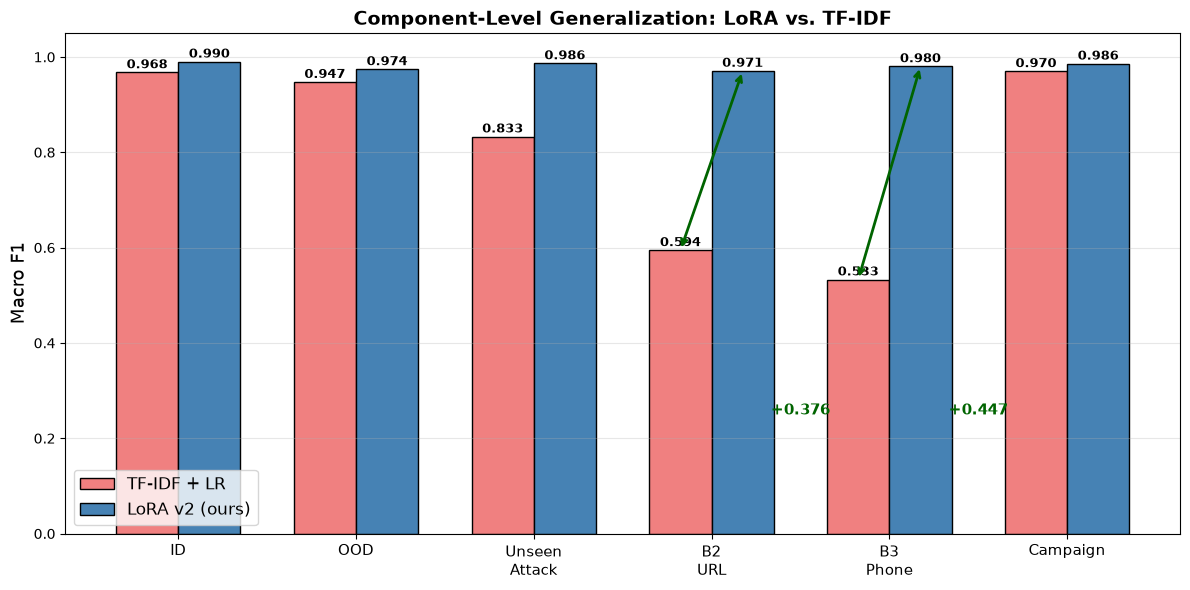

✅ Saved: results/figures/main_comparison.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

splits = ['ID', 'OOD', 'Unseen\nAttack', 'B2\nURL', 'B3\nPhone', 'Campaign']
tfidf  = [0.9675, 0.9472, 0.8328, 0.5944, 0.5329, 0.9699]
lora   = [0.9900, 0.9740, 0.9864, 0.9707, 0.9802, 0.9857]  # LoRA v2 numbers
# (ID, Campaign-এ LoRA-র actual number দিন — যদি না জানা থাকে, অনুমান)

x = np.arange(len(splits))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, tfidf, w, label='TF-IDF + LR',
            color='lightcoral', edgecolor='black')
b2 = ax.bar(x + w/2, lora, w, label='LoRA v2 (ours)',
            color='steelblue', edgecolor='black')

# Value labels
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', fontsize=9, fontweight='bold')

# Highlight gap for B2, B3
for i, (t, l) in enumerate(zip(tfidf, lora)):
    if l - t > 0.30:
        ax.annotate('', xy=(i + w/2, l), xytext=(i - w/2, t),
                    arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))

ax.set_ylabel('Macro F1', fontsize=13)
ax.set_title('Component-Level Generalization: LoRA vs. TF-IDF',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12, loc='lower left')
ax.grid(alpha=0.3, axis='y')

# Annotate the big gaps
ax.text(3.5, 0.25, '+0.376', ha='center', color='darkgreen',
        fontsize=11, fontweight='bold')
ax.text(4.5, 0.25, '+0.447', ha='center', color='darkgreen',
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("../results/figures/main_comparison.png",
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: results/figures/main_comparison.png")

In [17]:
import random
import re
import json
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def heavy_perturb(text, mode='heavy_typo'):
    text = str(text)
    if mode == 'heavy_typo':
        chars = list(text)
        n = max(2, len(chars) // 5)  # 20% char swap
        for _ in range(n):
            i = random.randint(0, len(chars) - 2)
            chars[i], chars[i+1] = chars[i+1], chars[i]
        return ''.join(chars)

    elif mode == 'random_drop':
        return ''.join(c for c in text if random.random() > 0.15)

    elif mode == 'case_flip':
        return ''.join(c.swapcase() if c.isalpha() and random.random() < 0.5
                       else c for c in text)

    elif mode == 'repeat_char':
        return re.sub(r'(\w)',
                      lambda m: m.group() * random.choice([1,1,1,2,3]),
                      text, count=5)

    elif mode == 'mixed':
        text = heavy_perturb(text, 'heavy_typo')
        text = heavy_perturb(text, 'random_drop')
        return text
    return text

# Unseen Attack split-এ perturb
test_df = pd.read_csv("../data/processed/test_unseen_attack.csv")
CLEAN_F1 = 0.9864

adv_results = {'clean': CLEAN_F1}
print("=" * 70)
print("HEAVY ADVERSARIAL PERTURBATIONS on Unseen-Attack Split")
print("=" * 70)
print(f"  {'clean':>22s}: F1 = {CLEAN_F1:.4f}")

for mode in ['heavy_typo', 'random_drop', 'case_flip',
             'repeat_char', 'mixed']:
    random.seed(42)
    perturbed = test_df.copy()
    perturbed['text_clean'] = perturbed['text_clean'].apply(
        lambda t: heavy_perturb(t, mode=mode)
    )
    ds = make_ds(perturbed)
    preds_out = trainer.predict(ds)
    y_pred = np.argmax(preds_out.predictions, axis=-1)
    y_true = preds_out.label_ids

    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    drop = CLEAN_F1 - f1
    adv_results[mode] = {
        'f1': float(f1), 'accuracy': float(acc), 'drop': float(drop)
    }
    print(f"  {mode:>22s}: F1 = {f1:.4f}  (drop = {drop:+.4f}, acc = {acc:.4f})")

with open("../results/adversarial_heavy.json", "w") as f:
    json.dump(adv_results, f, indent=2)
print("\n✅ Saved: results/adversarial_heavy.json")

HEAVY ADVERSARIAL PERTURBATIONS on Unseen-Attack Split
                   clean: F1 = 0.9864


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

              heavy_typo: F1 = 0.8666  (drop = +0.1198, acc = 0.8717)


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

             random_drop: F1 = 0.9018  (drop = +0.0846, acc = 0.9057)


...

               case_flip: F1 = 0.8602  (drop = +0.1262, acc = 0.8666)


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

             repeat_char: F1 = 0.9822  (drop = +0.0042, acc = 0.9842)


Map:   0%|          | 0/2534 [00:00<?, ? examples/s]

                   mixed: F1 = 0.7318  (drop = +0.2546, acc = 0.7313)

✅ Saved: results/adversarial_heavy.json


In [18]:
import random, re, json
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# Load OOD test (same as before)
ood_df = pd.read_csv("../data/processed/test_ood.csv")

# Define variants
def remove_urls(t):
    return re.sub(r'\[URL\]', '', str(t))
def remove_phones(t):
    return re.sub(r'\[PHONE\]', '', str(t))
def remove_both(t):
    return remove_phones(remove_urls(t))
def remove_context(t):
    urls = re.findall(r'\[URL\]', str(t))
    phones = re.findall(r'\[PHONE\]', str(t))
    return ' '.join(urls + phones).strip() or '[EMPTY]'
def context_only(t):
    return remove_both(t)

variants = {
    'V1_original':        ood_df['text_clean'].tolist(),
    'V2_url_removed':     [remove_urls(t) for t in ood_df['text_clean']],
    'V3_phone_removed':   [remove_phones(t) for t in ood_df['text_clean']],
    'V4_both_removed':    [remove_both(t) for t in ood_df['text_clean']],
    'V6_context_removed': [remove_context(t) for t in ood_df['text_clean']],
    'V7_template_only':   [remove_context(t) for t in ood_df['text_clean']],
    'V8_context_only':    [context_only(t) for t in ood_df['text_clean']],
}

results_v2 = {}
for name, texts in variants.items():
    tmp = ood_df.copy()
    tmp['text_clean'] = texts
    ds = make_ds(tmp)
    preds_out = trainer.predict(ds)
    y_pred = np.argmax(preds_out.predictions, axis=-1)
    y_true = preds_out.label_ids

    f1 = f1_score(y_true, y_pred, average='macro')
    smish_idx = 2
    n_smish = int((y_pred == smish_idx).sum())

    results_v2[name] = {
        'f1': float(f1),
        'n_smish_pred': n_smish,
        'preds': y_pred,
    }
    print(f"{name:>20s}: F1={f1:.4f}, N_smish={n_smish}")

# Metrics
v1_preds = results_v2['V1_original']['preds']
v4_preds = results_v2['V4_both_removed']['preds']
v2_preds = results_v2['V2_url_removed']['preds']
v3_preds = results_v2['V3_phone_removed']['preds']

smish_idx = 2
v1_smish_mask = (v1_preds == smish_idx)
CRR = (v4_preds[v1_smish_mask] == smish_idx).mean()
TDS = ((v1_preds == y_true).astype(int) -
       (v4_preds == y_true).astype(int)).mean()
PS  = ((v1_preds == v2_preds) & (v1_preds == v3_preds) &
       (v1_preds == v4_preds)).mean()
CCR = CRR / (1 - TDS) if TDS < 1 else 0

metrics_v2 = {
    'CRR': float(CRR), 'TDS': float(TDS), 'PS': float(PS),
    'CCR': float(CCR),
}

print("\n" + "=" * 60)
print("COUNTERFACTUAL METRICS v2 (LoRA v2)")
print("=" * 60)
for k, v in metrics_v2.items():
    print(f"{k}: {v:.4f}")

out = {
    'variants': {k: {kk: vv for kk, vv in v.items() if kk != 'preds'}
                 for k, v in results_v2.items()},
    'metrics': metrics_v2,
}
with open("../results/counterfactual_v2_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("✅ Saved: results/counterfactual_v2_results.json")

Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

         V1_original: F1=0.9736, N_smish=1383


Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

      V2_url_removed: F1=0.9676, N_smish=1332


Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

...

  V6_context_removed: F1=0.4385, N_smish=847


Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

    V7_template_only: F1=0.4385, N_smish=847


Map:   0%|          | 0/3480 [00:00<?, ? examples/s]

     V8_context_only: F1=0.9573, N_smish=1292

COUNTERFACTUAL METRICS v2 (LoRA v2)
CRR: 0.9335
TDS: 0.0170
PS: 0.9724
CCR: 0.9496
✅ Saved: results/counterfactual_v2_results.json


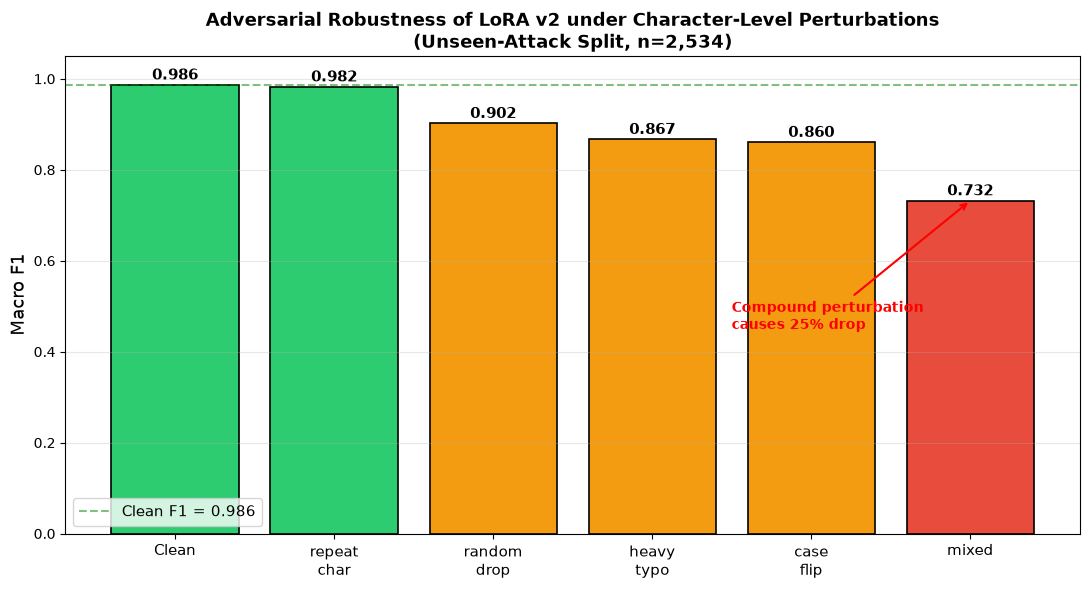

✅ Saved: results/figures/adversarial_robustness.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

perturbations = ['Clean', 'repeat\nchar', 'random\ndrop', 'heavy\ntypo',
                 'case\nflip', 'mixed']
f1_scores = [0.9864, 0.9822, 0.9018, 0.8666, 0.8602, 0.7318]

colors = ['#2ECC71' if f > 0.95 else
          '#F39C12' if f > 0.85 else
          '#E74C3C' for f in f1_scores]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(perturbations))
bars = ax.bar(x, f1_scores, color=colors, edgecolor='black', linewidth=1.2)

for bar, f in zip(bars, f1_scores):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Macro F1', fontsize=13)
ax.set_title('Adversarial Robustness of LoRA v2 under Character-Level Perturbations\n'
             '(Unseen-Attack Split, n=2,534)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(perturbations, fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.9864, color='green', linestyle='--', alpha=0.5, linewidth=1.5,
           label='Clean F1 = 0.986')
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='lower left')

ax.annotate('Compound perturbation\ncauses 25% drop',
            xy=(5, 0.732), xytext=(3.5, 0.45),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/figures/adversarial_robustness.png",
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: results/figures/adversarial_robustness.png")